In [157]:
# Supressing Warnings
import warnings
warnings.filterwarnings('ignore')

In [158]:
# Importing standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Import sklearn
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from collections import Counter # need to figure out the use!
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, classification_report # need to figure out what is 'classification_report'

In [159]:
data = pd.read_csv('dataset.csv')

### Step 1: Understand and explore data

In [160]:
# Sex: male or female
# Age: Age of the patient
# Current Smoker: whether or not the patient is a current smoker 
# Cigs Per Day: the number of cigarettes that the person smoked on average in one day
# BP Meds: whether or not the patient was on blood pressure medication 
# Prevalent Stroke: whether or not the patient had previously had a stroke 
# Prevalent Hyp: whether or not the patient was hypertensive 
# Diabetes: whether or not the patient had diabetes
# Tot Chol: total cholesterol level 
# Sys BP: systolic blood pressure 
# Dia BP: diastolic blood pressure 
# BMI: Body Mass Index 
# Heart Rate: heart rate 
# Glucose: glucose level 

#Predict variable (desired target)
# 10 year risk of coronary heart disease CHD (binary: “1”, means “Yes”, “0” means “No”)

In [161]:
data.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4,0,0.0,0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2,0,0.0,0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,1,20.0,0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3,1,30.0,0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3,1,23.0,0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [162]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4238 non-null   int64  
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4238 non-null   int64  
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(7), int64(9)
memory usage: 529.9 KB


Missing values

In [163]:
data.isna().sum()

male                 0
age                  0
education            0
currentSmoker        0
cigsPerDay          29
BPMeds               0
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [164]:
for column in data.columns:
    print(column)
    print(data[column].unique())

male
[1 0]
age
[39 46 48 61 43 63 45 52 50 41 38 42 44 47 60 35 36 59 54 37 56 53 49 65
 51 62 40 67 57 66 64 55 58 34 68 33 70 32 69]
education
[4 2 1 3]
currentSmoker
[0 1]
cigsPerDay
[ 0. 20. 30. 23. 15.  9. 10.  5. 35. 43.  1. 40.  3.  2. nan 12.  4. 18.
 25. 60. 14. 45.  8. 50. 13. 11.  7.  6. 38. 29. 17. 16. 19. 70.]
BPMeds
[0 1]
prevalentStroke
[0 1]
prevalentHyp
[0 1]
diabetes
[0 1]
totChol
[195. 250. 245. 225. 285. 228. 205. 313. 260. 254. 247. 294. 332. 226.
 221. 232. 291. 190. 185. 234. 215. 270. 272. 295. 209. 175. 214. 257.
 178. 233. 180. 243. 237.  nan 311. 208. 252. 261. 179. 194. 267. 216.
 240. 266. 255. 220. 235. 212. 223. 300. 302. 248. 200. 189. 258. 202.
 213. 183. 274. 170. 210. 197. 326. 188. 256. 244. 193. 239. 296. 269.
 275. 268. 265. 173. 273. 290. 278. 264. 282. 241. 288. 222. 303. 246.
 150. 187. 286. 154. 279. 293. 259. 219. 230. 320. 312. 165. 159. 174.
 242. 301. 167. 308. 325. 229. 236. 224. 253. 464. 171. 186. 227. 249.
 176. 163. 191. 263. 196. 310.

### Step 2: Missing value imputation

In [165]:
# Numerical columns 
numerical_columns = ['cigsPerDay', 'totChol', 'BMI', 'heartRate', 'glucose']
for column in numerical_columns:
    print(f"{column}: {data[column].isna().sum()} -> {data[column].median()} ")
    data[column].fillna(data[column].median(), inplace=True)

cigsPerDay: 29 -> 0.0 
totChol: 50 -> 234.0 
BMI: 19 -> 25.4 
heartRate: 1 -> 75.0 
glucose: 388 -> 78.0 


In [166]:
data.isna().sum()

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

### Step 3: Univariate data analysis/visualization

Hypothesis testing section

In [167]:
data.head(10)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4,0,0.0,0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2,0,0.0,0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,1,20.0,0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3,1,30.0,0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3,1,23.0,0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
5,0,43,2,0,0.0,0,0,1,0,228.0,180.0,110.0,30.30,77.0,99.0,0
6,0,63,1,0,0.0,0,0,0,0,205.0,138.0,71.0,33.11,60.0,85.0,1
7,0,45,2,1,20.0,0,0,0,0,313.0,100.0,71.0,21.68,79.0,78.0,0
8,1,52,1,0,0.0,0,0,1,0,260.0,141.5,89.0,26.36,76.0,79.0,0
9,1,43,1,1,30.0,0,0,1,0,225.0,162.0,107.0,23.61,93.0,88.0,0


In [168]:
data.totChol.unique()

array([195., 250., 245., 225., 285., 228., 205., 313., 260., 254., 247.,
       294., 332., 226., 221., 232., 291., 190., 185., 234., 215., 270.,
       272., 295., 209., 175., 214., 257., 178., 233., 180., 243., 237.,
       311., 208., 252., 261., 179., 194., 267., 216., 240., 266., 255.,
       220., 235., 212., 223., 300., 302., 248., 200., 189., 258., 202.,
       213., 183., 274., 170., 210., 197., 326., 188., 256., 244., 193.,
       239., 296., 269., 275., 268., 265., 173., 273., 290., 278., 264.,
       282., 241., 288., 222., 303., 246., 150., 187., 286., 154., 279.,
       293., 259., 219., 230., 320., 312., 165., 159., 174., 242., 301.,
       167., 308., 325., 229., 236., 224., 253., 464., 171., 186., 227.,
       249., 176., 163., 191., 263., 196., 310., 164., 135., 238., 207.,
       342., 287., 182., 352., 284., 217., 203., 262., 129., 155., 323.,
       206., 283., 319., 304., 340., 328., 280., 368., 218., 276., 339.,
       231., 198., 177., 201., 277., 184., 199., 16

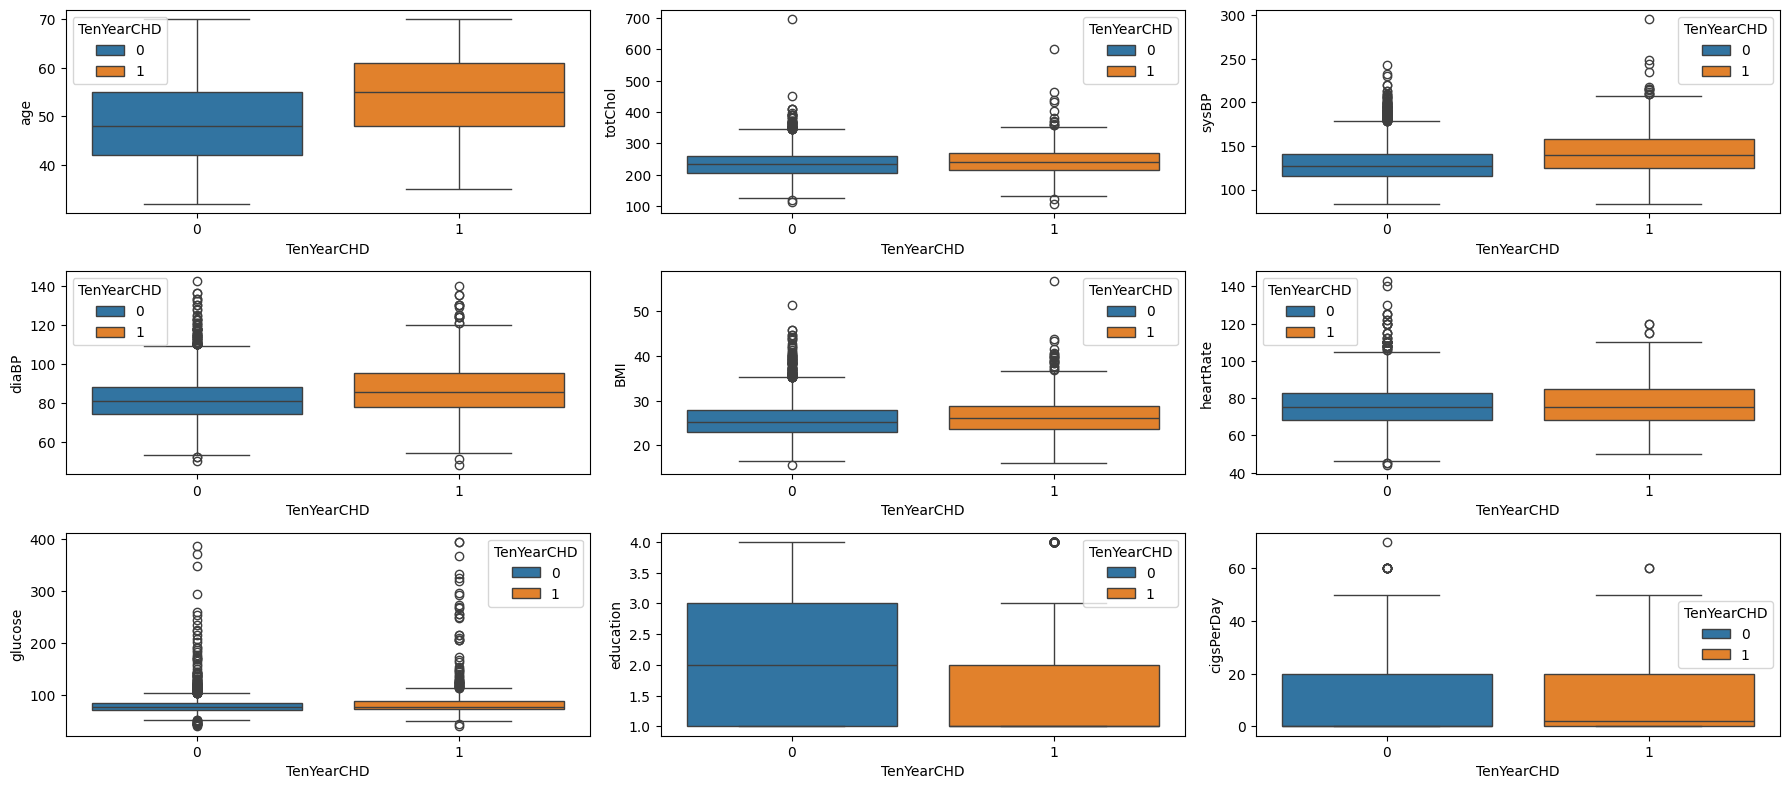

In [169]:
# Understanding correlation between dependent and independent variables
# Visually

# Numerical variables

fig = plt.figure(figsize=(18, 8))

# Age
plt.subplot(3, 3, 1)
sns.boxplot(data, x='TenYearCHD', y='age', hue='TenYearCHD')
# Cholestrol
plt.subplot(3, 3, 2)
sns.boxplot(data=data, x='TenYearCHD', y='totChol', hue='TenYearCHD')
# Blood Pressure
plt.subplot(3, 3, 3)
sns.boxplot(data=data, x='TenYearCHD', y='sysBP', hue='TenYearCHD')
# diaBP
plt.subplot(3, 3, 4)
sns.boxplot(data=data, x='TenYearCHD', y='diaBP', hue='TenYearCHD')
# BMI
plt.subplot(3, 3, 5)
sns.boxplot(data=data, x='TenYearCHD', y='BMI', hue='TenYearCHD')
# heartRate
plt.subplot(3, 3, 6)
sns.boxplot(data=data, x='TenYearCHD', y='heartRate', hue='TenYearCHD')
# glucose
plt.subplot(3, 3, 7)
sns.boxplot(data=data, x='TenYearCHD', y='glucose', hue='TenYearCHD')
# education
plt.subplot(3, 3, 8)
sns.boxplot(data=data, x='TenYearCHD', y='education', hue='TenYearCHD')
# cigsPerDay
plt.subplot(3, 3, 9)
sns.boxplot(data=data, x='TenYearCHD', y='cigsPerDay', hue='TenYearCHD')

plt.tight_layout()
plt.show()

Categorical variables

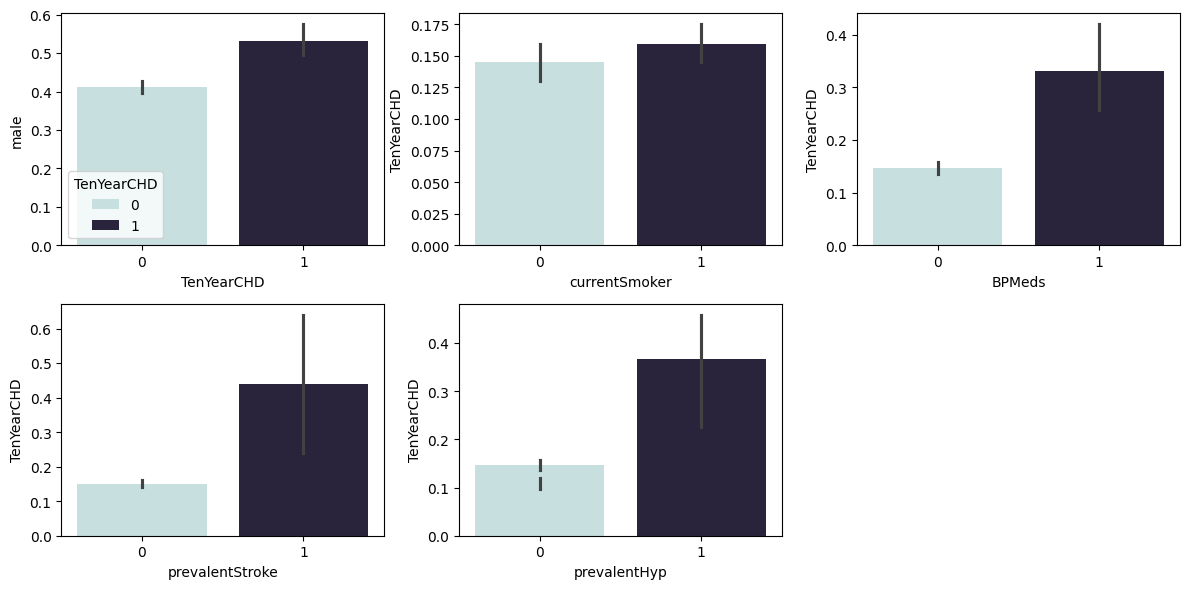

In [170]:
pallete = 'ch:start=.2,rot=-.3'
fig = plt.figure(figsize=(12, 6))

# Male
plt.subplot(2, 3, 1)
sns.barplot(data=data, x='TenYearCHD', y='male', hue='TenYearCHD', palette=pallete)
# Current Smoker
plt.subplot(2, 3, 2)
sns.barplot(data=data, x='currentSmoker', y='TenYearCHD', palette=pallete)
# BPMeds
plt.subplot(2, 3, 3)
sns.barplot(data=data, x='BPMeds', y='TenYearCHD', palette=pallete)
# prevalentStroke
plt.subplot(2, 3, 4)
sns.barplot(data=data, x='prevalentStroke', y='TenYearCHD', palette=pallete)
# prevalentHyp
plt.subplot(2, 3, 5)
sns.barplot(data=data, x='prevalentHyp', y='TenYearCHD', palette=pallete)
# diabetes
plt.subplot(2, 3, 5)
sns.barplot(data=data, x='diabetes', y='TenYearCHD', palette=pallete)

plt.tight_layout()
plt.show()

Correlation of output with numerical columns

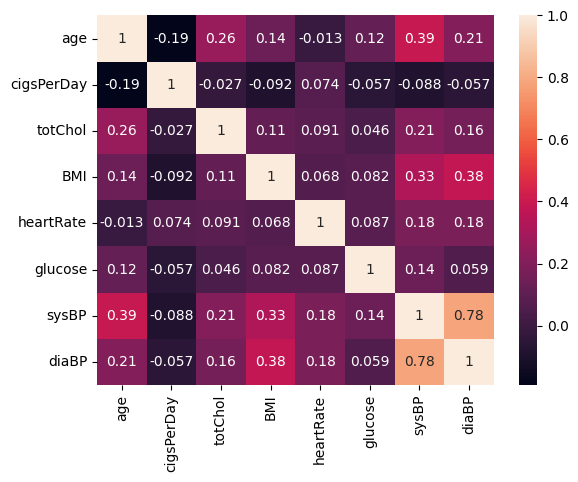

In [266]:
numerical_columns = ['age', 'cigsPerDay', 'totChol', 'BMI','heartRate', 'glucose', 'sysBP','diaBP']
fig = plt.figure()
sns.heatmap(data=data[numerical_columns].corr(), annot=True)

plt.show()

sysBP and diaBP have strong correlation</br>
SME: Trainer notes

sysBP: Systolic Blood Pressure - The pressure exerted when the heartbeats</br>
diaBP: Diastolic Blood Pressure - The pressure exerted on the walls of the arteries when the heart muscles relax in between two beats

Both systolic and diastolic blood pressure are important indicators of cardiovascular health, and both can be associated with an increased risk of heart disease. 

However, the relationship between blood pressure and heart disease is complex, and both systolic and diastolic pressure readings are often considered together to provide a more comprehensive assessment.

### Step 4: Converting variables into features

We had all variables in numeric format, hence no need to convert

In [172]:
def train_test_split_and_scale(data):
    y = data.pop('TenYearCHD')
    x = data
    features = x.columns
    x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.80, test_size=0.20, random_state=0)
    scaler = MinMaxScaler()
    x_train = scaler.fit_transform(x_train)
    x_test = scaler.transform(x_test)
    return x_train, x_test, y_train, y_test, features

In [174]:
x_train, x_test, y_train, y_test, features = train_test_split_and_scale(data)

Training data imbalance

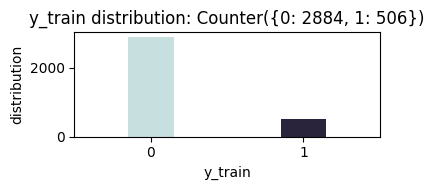

In [218]:
fig = plt.figure(figsize=(4, 2))
sns.barplot(Counter(y_train), palette=pallete, width=0.3)
plt.title(f'y_train distribution: {Counter(y_train)}')
plt.xlabel('y_train')
plt.ylabel('distribution')
plt.tight_layout()
plt.show()

In [220]:
Counter(y_test)

Counter({0: 710, 1: 138})

### Step 5: Train and evaluate model

In [210]:
def train_evaluate_model(x_train, x_test, y_train, y_test, classWeight=None):
    logistic_regression = LogisticRegression(class_weight=classWeight)
    # Train model
    model = logistic_regression.fit(x_train, y_train)
    # Predict
    lr_predictions = model.predict(x_test)
    ConfusionMatrix = confusion_matrix(y_test, lr_predictions)
    AccuracyScore = accuracy_score(y_test, lr_predictions)
    ClassificationReport = classification_report(y_test, lr_predictions)
    print(f"Confusion Matrix:\n{ConfusionMatrix}")
    print(f"True Positive: {ConfusionMatrix[0][0]}")
    print(f"False Negative: {ConfusionMatrix[0][1]}")
    print(f"False Positive: {ConfusionMatrix[1][0]}")
    print(f"True Negative: {ConfusionMatrix[1][1]}")
    print(f"Accuracy Score: {round(AccuracyScore*100, 1)}%")
    print(f"Classification Report:\n{ClassificationReport}")
    return model

In [211]:
model = train_evaluate_model(x_train, x_test, y_train, y_test)
print(f"Odds ratio: {model.coef_}")

Confusion Matrix:
[[710   0]
 [131   7]]
True Positive: 710
False Negative: 0
False Positive: 131
True Negative: 7
Accuracy Score: 84.6%
Classification Report:
              precision    recall  f1-score   support

           0       0.84      1.00      0.92       710
           1       1.00      0.05      0.10       138

    accuracy                           0.85       848
   macro avg       0.92      0.53      0.51       848
weighted avg       0.87      0.85      0.78       848

Odds ratio: [[ 0.42801294  2.26666149 -0.01811502  0.08932879  1.32715884  0.12900339
   0.87014703  0.41977921  0.52909796  0.86400177  1.59858089 -0.30173595
   0.25832886 -0.0757107   1.16065979]]


### Step 6: Improve Model

In [213]:
class_weight = {
    0: 1,
    1: 4
}

In [215]:
model = train_evaluate_model(x_train, x_test, y_train, y_test, classWeight=class_weight)
print(f"Odds ratio: {model.coef_}")

Confusion Matrix:
[[568 142]
 [ 61  77]]
True Positive: 568
False Negative: 142
False Positive: 61
True Negative: 77
Accuracy Score: 76.1%
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.80      0.85       710
           1       0.35      0.56      0.43       138

    accuracy                           0.76       848
   macro avg       0.63      0.68      0.64       848
weighted avg       0.81      0.76      0.78       848

Odds ratio: [[ 0.41622515  2.43734723 -0.00327385  0.10791877  1.43283817  0.15117309
   0.85553708  0.38551819  0.59087339  0.86619958  1.73226597 -0.36156429
   0.38202686 -0.11704     0.97779373]]


In [222]:
results = pd.DataFrame(model.predict_proba(x_test))
results.columns = ['class_0_probability', 'class_1_probability']
results['predicted_class'] = model.predict(x_test)
results.head()

,class_0_probability,class_1_probability,predicted_class
0,0.718657,0.281343,0
1,0.528738,0.471262,0
2,0.265090,0.734910,1
3,0.718933,0.281067,0
4,0.646953,0.353047,0


Save and reuse model

In [ ]:
import joblib
joblib.dump(model, 'model_classifier.pkl')

In [227]:
read_model = joblib.load('model_classifier.pkl')
read_model.predict(x_test)

array([0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,

### Step 7: Model Interpretation

Feature importance:

Odds ratio well higher than 1: Increase in fetaure value increases probability of event(heart risk) hapenning

Odds ratio well below 1: Increase in fetaure value decreases probability of event(heart risk) hapenning

Odds ration near 0: A feature with an odds ratio near zero typically suggests that the associated predictor has a strong negative impact on the odds of the event occurring.

Odds ratio near 1: indicates that feature may not be a strong predictor

In [237]:
log_odds_ratio = read_model.coef_[0]
print(f"Log odds ratio: {log_odds_ratio}")

Log odds ratio: [ 0.41622515  2.43734723 -0.00327385  0.10791877  1.43283817  0.15117309
  0.85553708  0.38551819  0.59087339  0.86619958  1.73226597 -0.36156429
  0.38202686 -0.11704     0.97779373]


In [238]:
odds_ratio = np.exp(log_odds_ratio)
print(f"Odds ratio: {odds_ratio}")

Odds ratio: [ 1.5162272  11.44264577  0.9967315   1.11395726  4.1905759   1.16319798
  2.35263761  1.47037606  1.80556469  2.3778568   5.65344995  0.69658581
  1.46525145  0.88954961  2.65858422]


In logistic regression, the coefficients are estimated on a log-odds scale. This means that a one-unit change in a predictor variable is associated with a change in the log odds of the outcome occurring.

To interpret these coefficients in a more intuitive and understandable way,</br>
specifically in terms of how they affect the odds of the outcome,</br>
one must convert them from the log-odds scale back to the odds scale.

This conversion is achieved by applying the exponential function, which in NumPy is np.exp()

In [240]:
for i in range(len(features)):
    print(f"Odds ratio for feature {features[i]}: {odds_ratio[i]}")

Odds ratio for feature male: 1.516227204498459
Odds ratio for feature age: 11.442645774702655
Odds ratio for feature education: 0.9967314995844363
Odds ratio for feature currentSmoker: 1.1139572583452906
Odds ratio for feature cigsPerDay: 4.1905759032950085
Odds ratio for feature BPMeds: 1.1631979799997096
Odds ratio for feature prevalentStroke: 2.3526376050423163
Odds ratio for feature prevalentHyp: 1.4703760574815679
Odds ratio for feature diabetes: 1.8055646918618509
Odds ratio for feature totChol: 2.3778568004979688
Odds ratio for feature sysBP: 5.653449952627674
Odds ratio for feature diaBP: 0.6965858145250924
Odds ratio for feature BMI: 1.4652514483442307
Odds ratio for feature heartRate: 0.8895496088491939
Odds ratio for feature glucose: 2.658584221992421


Plotting Odds ratios for features

In [241]:
results = pd.DataFrame()
results['features'] = features
results['odds ratio'] = odds_ratio

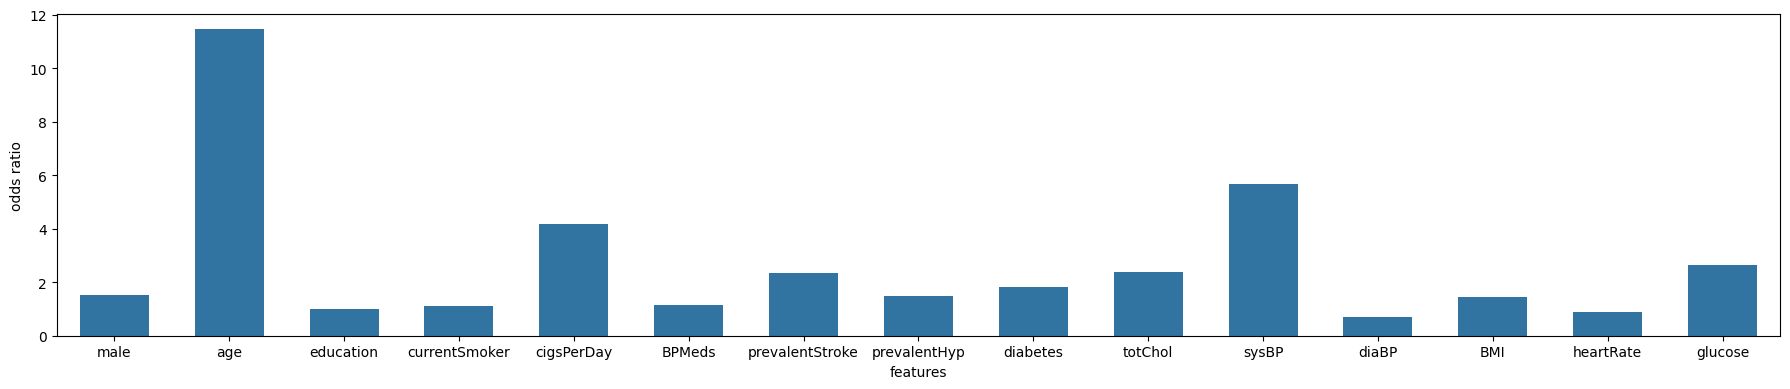

In [264]:
fig = plt.figure(figsize=(18, 4))
sns.barplot(data=results, x='features', y='odds ratio', color='tab:blue', width=0.6)
plt.tight_layout()
plt.show()